<a href="https://colab.research.google.com/github/Pardhu-2005/Internship-task1/blob/main/apssdc_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Load and Explore the Data
import pandas as pd

# Load the CSV file
df = pd.read_csv("ipl_centuries.csv")

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Show the number of rows and columns
print(f"\nShape of the dataset: {df.shape}")

# Show data types and non-null counts
print("\nData Info:")
print(df.info())

# Show basic statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe(include='all'))

First 5 rows of the dataset:
   No Score  Balls  Strike Rate             Player                   Team  \
0   1  158*     73       216.43   Brendon McCullum  Kolkata Knight Riders   
1   2  116*     54       214.81     Michael Hussey    Chennai Super Kings   
2   3  117*     53       220.75     Andrew Symonds        Deccan Chargers   
3   4  109*     47       231.91     Adam Gilchrist        Deccan Chargers   
4   5  114*     48       237.50  Sanath Jayasuriya         Mumbai Indians   

                    Opposition  Innings  \
0  Royal Challengers Bangalore        1   
1              Kings XI Punjab        1   
2             Rajasthan Royals        1   
3               Mumbai Indians        2   
4          Chennai Super Kings        2   

                                        Venue        City       Date Result  
0                      M. Chinnaswamy Stadium   Bangalore  18-Apr-08    Won  
1                                 PCA Stadium      Mohali  19-Apr-08    Won  
2  Rajiv Gandhi

In [ ]:
# Step 2: Data Cleaning
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Drop rows with any missing values (if necessary)
df_cleaned = df.dropna()

# Fix column data types if needed (e.g., convert Date column)
if 'Date' in df_cleaned.columns:
    df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

# Confirm cleaning
print("\nData after cleaning:")
print(df_cleaned.info())


Missing values in each column:
No             0
Score          0
Balls          0
Strike Rate    0
Player         0
Team           0
Opposition     0
Innings        0
Venue          0
City           0
Date           0
Result         0
dtype: int64

Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   No           108 non-null    int64         
 1   Score        108 non-null    object        
 2   Balls        108 non-null    int64         
 3   Strike Rate  108 non-null    float64       
 4   Player       108 non-null    object        
 5   Team         108 non-null    object        
 6   Opposition   108 non-null    object        
 7   Innings      108 non-null    int64         
 8   Venue        108 non-null    object        
 9   City         108 non-null    object        
 10  Date         108 non-null    dat

/tmp/ipython-input-7-4056479677.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])


In [ ]:
# Step 3: Data Analysis

# Most centuries by a player
top_players = df_cleaned['Player'].value_counts().head(10)
print("\nTop 10 players with most centuries:")
print(top_players)

# Most centuries by team
top_teams = df_cleaned['Team'].value_counts().head(10)
print("\nTop 10 teams with most centuries:")
print(top_teams)

# Centuries per year
df_cleaned['Year'] = df_cleaned['Date'].dt.year
centuries_per_year = df_cleaned['Year'].value_counts().sort_index()
print("\nNumber of centuries per year:")
print(centuries_per_year)

# Player with the most centuries
most_centuries_player = df['Player'].value_counts().idxmax()
century_count = df['Player'].value_counts().max()

print(f"\n🏅 Player with the most centuries: {most_centuries_player} ({century_count} centuries)")

if 'Venue' in df.columns:
    top_venues = df['Venue'].value_counts().head(10)
    print("\n🏟️ Top venues where most centuries were scored:")
    print(top_venues)
else:
    print("⚠️ 'Ground' column not available in dataset.")







Top 10 players with most centuries:
Player
Virat Kohli       8
Jos Buttler       7
Chris Gayle       6
KL Rahul          5
David Warner      4
Shane Watson      4
Shubman Gill      4
Sanju Samson      3
AB de Villiers    3
Adam Gilchrist    2
Name: count, dtype: int64

Top 10 teams with most centuries:
Team
Rajasthan Royals               18
Royal Challengers Bangalore    17
Kings XI Punjab                13
Chennai Super Kings            10
Mumbai Indians                  8
Sunrisers Hyderabad             8
Delhi Daredevils                8
Gujarat Titans                  6
Lucknow Super Giants            5
Punjab Kings                    3
Name: count, dtype: int64

Number of centuries per year:
Year
2008     6
2009     2
2010     4
2011     6
2012     6
2013     4
2014     3
2015     4
2016     7
2017     5
2018     5
2019     6
2020     5
2021     4
2022     8
2023    12
2024    14
2025     7
Name: count, dtype: int64

🏅 Player with the most centuries: Virat Kohli (8 centuries)

🏟️

/tmp/ipython-input-9-590543680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette='crest')


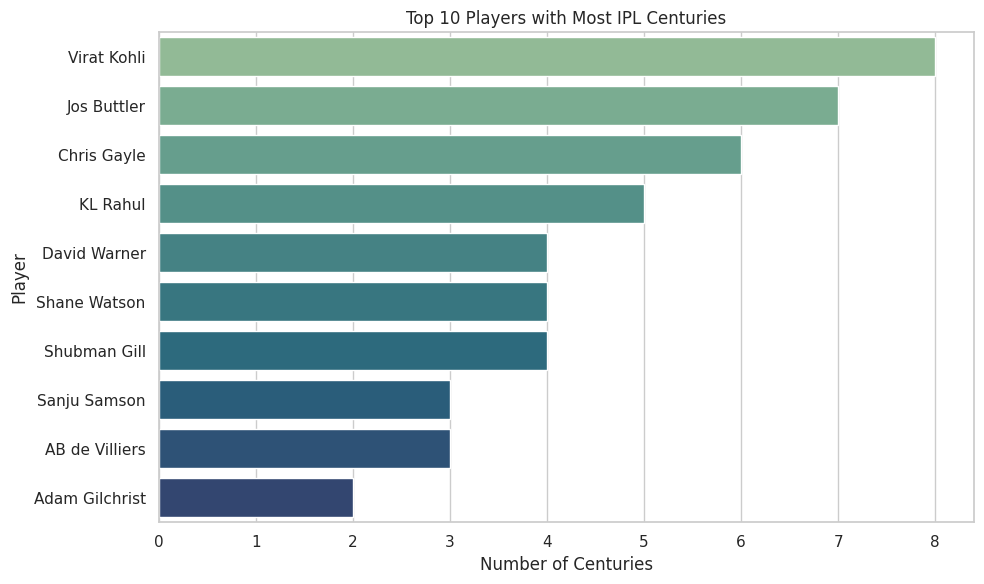

/tmp/ipython-input-9-590543680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette='magma')


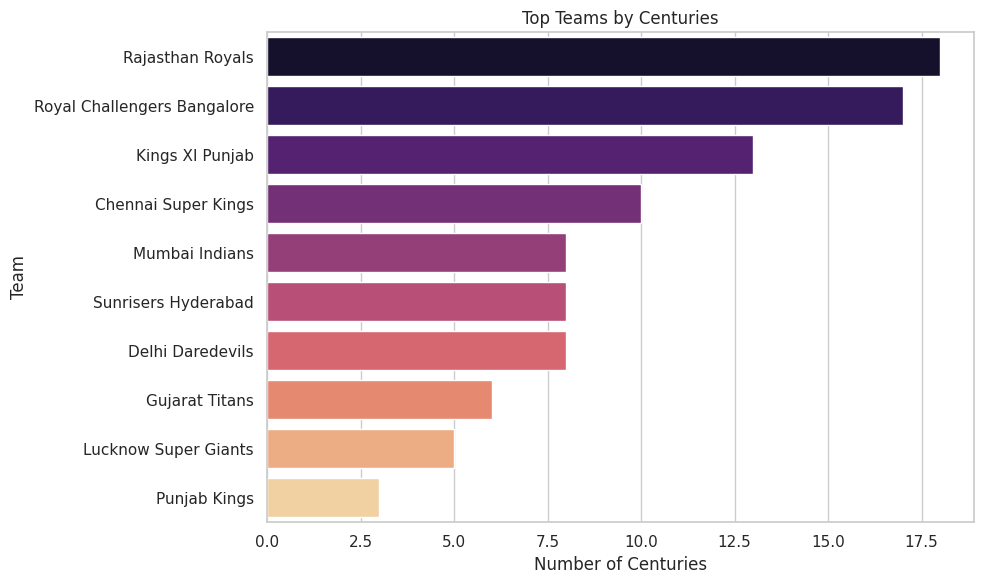

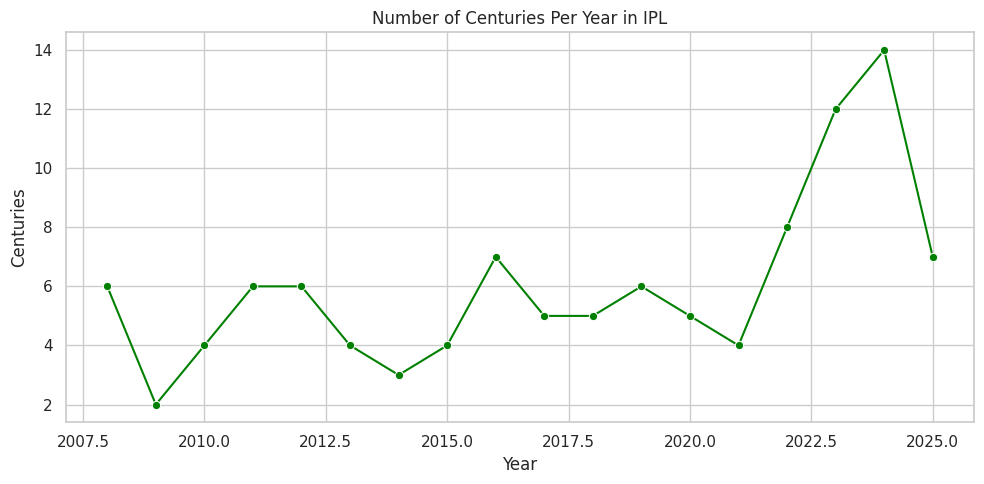

/tmp/ipython-input-9-590543680.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=centuries_per_venue.values, y=centuries_per_venue.index, palette='viridis')


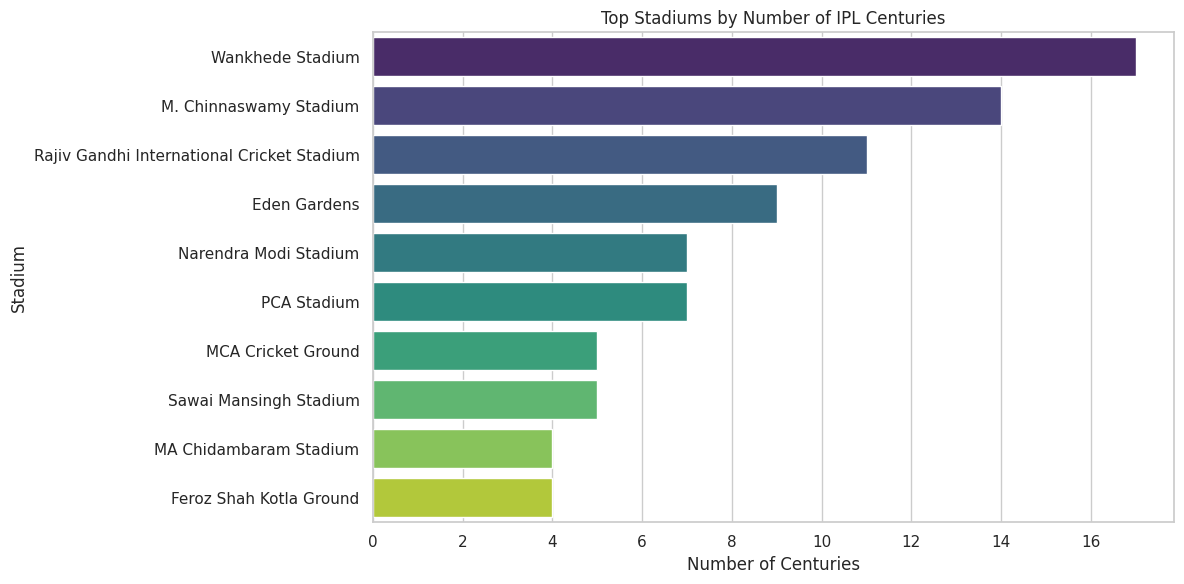

In [ ]:
# Step 4: Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style
sns.set(style="whitegrid")

# Plot top 10 players with most centuries
plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index, palette='crest')
plt.title("Top 10 Players with Most IPL Centuries")
plt.xlabel("Number of Centuries")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

# Plot centuries by team
plt.figure(figsize=(10,6))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='magma')
plt.title("Top Teams by Centuries")
plt.xlabel("Number of Centuries")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

# Plot centuries per year
plt.figure(figsize=(10,5))
sns.lineplot(x=centuries_per_year.index, y=centuries_per_year.values, marker='o', color='green')
plt.title("Number of Centuries Per Year in IPL")
plt.xlabel("Year")
plt.ylabel("Centuries")
plt.grid(True)
plt.tight_layout()
plt.show()



# Count the number of centuries at each stadium
centuries_per_venue = df['Venue'].value_counts().head(10)  # top 10 venues

# Set a clean visual style
sns.set(style="whitegrid")

# Plot centuries per stadium
plt.figure(figsize=(12,6))
sns.barplot(x=centuries_per_venue.values, y=centuries_per_venue.index, palette='viridis')
plt.title("Top Stadiums by Number of IPL Centuries")
plt.xlabel("Number of Centuries")
plt.ylabel("Stadium")
plt.tight_layout()
plt.show()









/tmp/ipython-input-8-3259706107.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=centuries_per_venue.values, y=centuries_per_venue.index, palette='viridis')


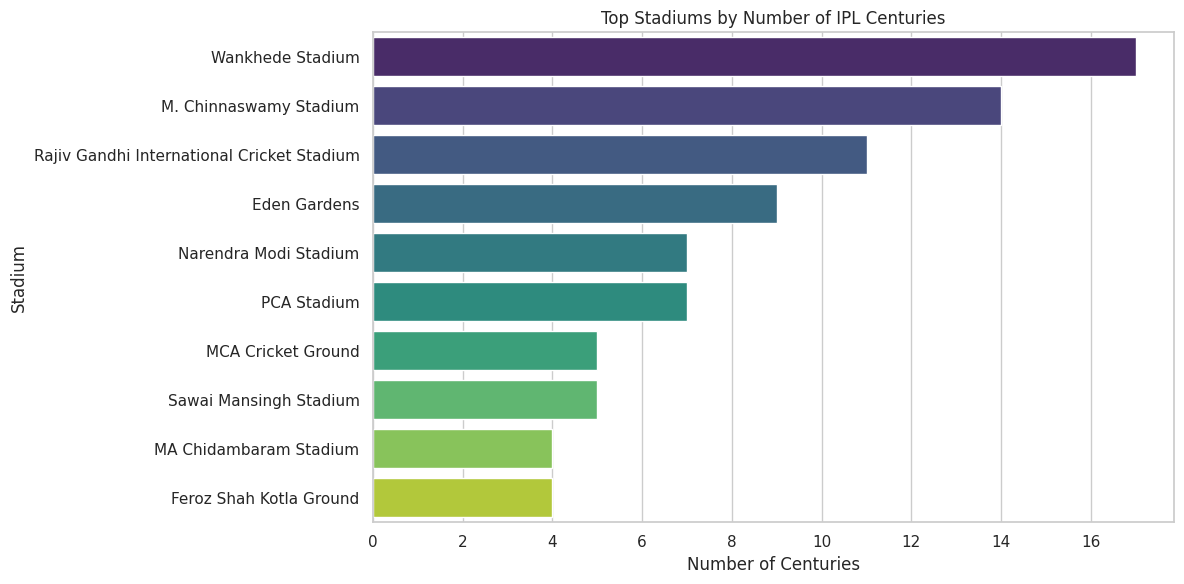